In [ ]:
#NTSS < 3.5 , crypt < 50 , seed of the split = 42, random state cross validation = 8, 

In [ ]:
"""
=== PREZADO TEST SET ===
Selected papers (5):
  - FLASH Irradiation Results in Reduced Severe Skin Toxicity  (5 samples)
  - Design, Implementation, and in Vivo Validation of a Novel Proton FLASH Radiation Therapy System  (2 samples)
  - Effects of dose-rate on the radiation response of rat skin  (5 samples)
  - Long-term neurocognitive benefits of FLASH radiotherapy driven by reduced reactive oxygen species  (3 samples)
  - First demonstration of the FLASH effect with ultrahigh dose-rate high-energy X-rays  (3 samples)
Total samples in PREZADO test: 18

=== TOSCHINI TEST SET ===
Selected papers (1):
  - Levy et al., 2020  (2 samples)
Total samples in TOSCHINI test: 2

=== GLOBAL SPLIT SUMMARY ===
Original dataset size: 85
Train samples: 65
Test samples:  20
Excluded group 'Ruan et al., 2021' kept in TRAIN: 21 samples
Check: train + test = 85
"""

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

In [2]:
from src.utils.io import load_excel

DATA_DIR = PROJECT_ROOT / "data"

test = load_excel(
    DATA_DIR /
    "processed" /
    "processed_elec-prot" /
    "elec-prot_test.xlsx"
)

In [3]:
train = load_excel(
    DATA_DIR /
    "processed" /
    "processed_elec-prot" /
    "augmented_3.xlsx"
)

In [4]:
features = ["MDR", "PW", "Frequency", "NoP", "TD", "Particle", "Target"]

X_train = train[features]
y_train = train["Endpoint"]

X_test = test[features]
y_test = test["Endpoint"]

titles = train["Title"]

In [5]:
# RANDOM FOREST

In [5]:
from src.models.random_forest import train_random_forest
model = train_random_forest(X_train, y_train, n = 2000, msl = 10, mss = 20)

In [6]:
from src.models.cross_validation import cross_validate_grouped_stratified
cross_validate_grouped_stratified(model, X_train, y_train, titles)


=== Fold composition summary ===

Fold 1:
  Train groups: 14
  Test groups:  2
  Train samples: 160
  Test samples:  100

Fold 2:
  Train groups: 13
  Test groups:  3
  Train samples: 212
  Test samples:  48

Fold 3:
  Train groups: 12
  Test groups:  4
  Train samples: 224
  Test samples:  36

Fold 4:
  Train groups: 15
  Test groups:  1
  Train samples: 228
  Test samples:  32

Fold 5:
  Train groups: 10
  Test groups:  6
  Train samples: 216
  Test samples:  44



{'f1_scores': array([0.83211679, 0.8       , 0.76923077, 0.4       , 0.33333333]),
 'accuracy_scores': array([0.77      , 0.75      , 0.75      , 0.25      , 0.63636364]),
 'f1_mean': np.float64(0.626936178177054),
 'f1_std': np.float64(0.2144763760007861),
 'acc_mean': np.float64(0.6312727272727272),
 'acc_std': np.float64(0.19638350067875607)}

In [9]:
from src.models.evaluation import evaluate_model
evaluate_model(model, X_test, y_test)

{'accuracy': 0.6,
 'f1': 0.5555555555555556,
 'confusion_matrix': array([[7, 5],
        [3, 5]]),
 'fpr': array([0.        , 0.        , 0.        , 0.16666667, 0.16666667,
        0.33333333, 0.33333333, 0.58333333, 0.58333333, 0.66666667,
        0.66666667, 1.        , 1.        ]),
 'tpr': array([0.   , 0.125, 0.25 , 0.25 , 0.5  , 0.5  , 0.625, 0.625, 0.75 ,
        0.75 , 0.875, 0.875, 1.   ]),
 'roc_auc': 0.6354166666666667}

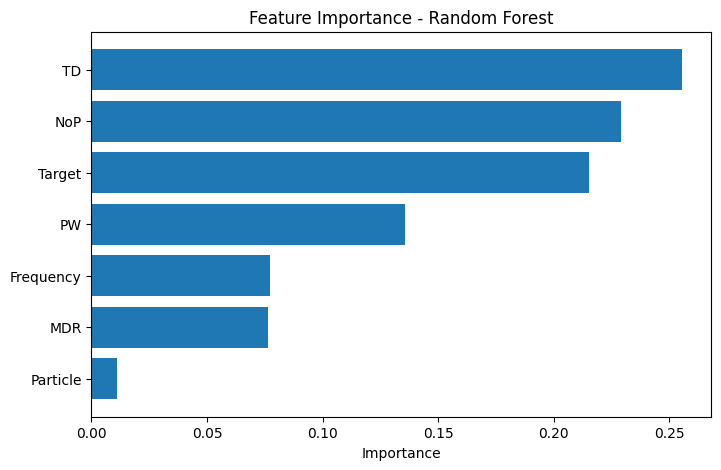

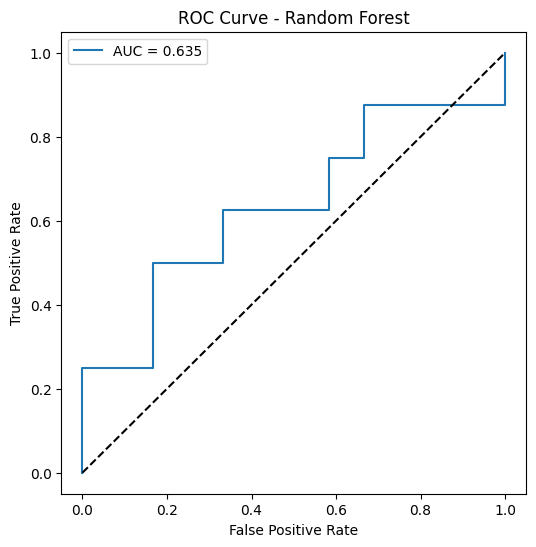

In [10]:
from src.models.evaluation import get_feature_importance
from src.visualization.plots import plot_feature_importance, plot_roc_curve

feature_importance = get_feature_importance(model, features)
plot_feature_importance(feature_importance, "Random Forest")
plot_roc_curve(model, X_test, y_test, "Random Forest")

In [15]:
from src.visualization.plots import grouped_permutation_importance

imp = grouped_permutation_importance(
    model=model,
    X=X_train,
    y=y_train,
    titles=titles,
    folds=5,
    n_repeats=30,
    plot=True
)


ImportError: cannot import name 'grouped_permutation_importance' from 'src.visualization.plots' (c:\Users\silvi\Desktop\mastersthesis\src\visualization\plots.py)

In [10]:
# XGBOOST

In [16]:
from src.models.xgboost import train_xgb

model_xgb = train_xgb(X_train, y_train, n=2000, md=4, ra=0.5)

In [17]:
from src.models.cross_validation import cross_validate_grouped_stratified
cross_validate_grouped_stratified(model_xgb, X_train, y_train, titles)


=== Fold composition summary ===

Fold 1:
  Train groups: 14
  Test groups:  2
  Train samples: 160
  Test samples:  100

Fold 2:
  Train groups: 13
  Test groups:  3
  Train samples: 212
  Test samples:  48

Fold 3:
  Train groups: 12
  Test groups:  4
  Train samples: 224
  Test samples:  36

Fold 4:
  Train groups: 15
  Test groups:  1
  Train samples: 228
  Test samples:  32

Fold 5:
  Train groups: 10
  Test groups:  6
  Train samples: 216
  Test samples:  44



{'f1_scores': array([0.74015748, 0.8       , 0.46153846, 0.4       , 0.57142857]),
 'accuracy_scores': array([0.67      , 0.75      , 0.41666667, 0.25      , 0.72727273]),
 'f1_mean': np.float64(0.5946249026563987),
 'f1_std': np.float64(0.15458821759417563),
 'acc_mean': np.float64(0.5627878787878788),
 'acc_std': np.float64(0.19635974556564342)}

In [18]:
from src.models.evaluation import evaluate_model

evaluate_model(model_xgb, X_test, y_test)

{'accuracy': 0.55,
 'f1': 0.5714285714285714,
 'confusion_matrix': array([[5, 7],
        [2, 6]]),
 'fpr': array([0.        , 0.        , 0.        , 0.33333333, 0.33333333,
        0.41666667, 0.41666667, 0.66666667, 0.66666667, 1.        ,
        1.        ]),
 'tpr': array([0.   , 0.125, 0.25 , 0.25 , 0.625, 0.625, 0.75 , 0.75 , 0.875,
        0.875, 1.   ]),
 'roc_auc': 0.6145833333333333}

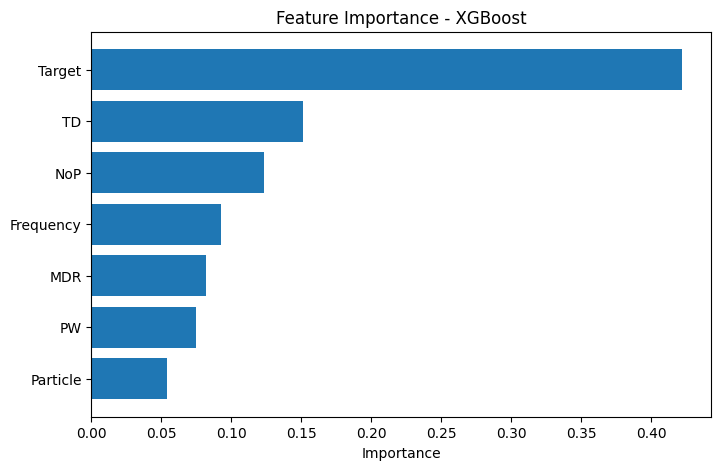

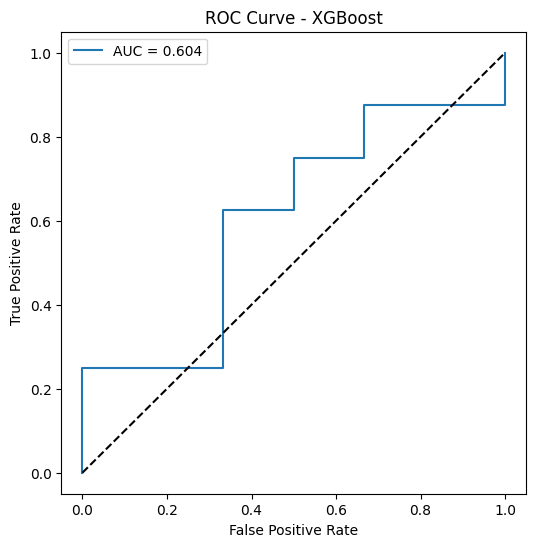

In [14]:
from src.models.evaluation import get_feature_importance
from src.visualization.plots import plot_feature_importance, plot_roc_curve

feature_importance_xgb = get_feature_importance(model_xgb, features)
plot_feature_importance(feature_importance_xgb, "XGBoost")
plot_roc_curve(model_xgb, X_test, y_test, "XGBoost")

In [32]:
from src.models.evaluation import cross_validate_model
cross_validate_model(model_xgb, X_train, y_train)

ImportError: cannot import name 'cross_validate_model' from 'src.models.evaluation' (c:\Users\silvi\Desktop\mastersthesis\src\models\evaluation.py)

In [15]:
# Neural Network

In [16]:
from src.models.neural_network import build_mlp
model_nn = build_mlp(input_dim=X_train.shape[1])

In [17]:
from sklearn.model_selection import train_test_split

X_train_nn, X_test_nn, y_train_nn, y_test_nn = train_test_split(
    X_train, y_train, test_size=0.2, random_state=11, stratify=y_train
)


from tensorflow.keras.callbacks import EarlyStopping
es = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True
)

history = model_nn.fit(
    X_train, y_train,
    validation_data=(X_test_nn, y_test_nn),
    epochs=200,
    batch_size=32,
    callbacks=[es],
    verbose=1
)


Epoch 1/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.5312 - loss: 0.6922 - val_accuracy: 0.5385 - val_loss: 0.6929
Epoch 2/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5312 - loss: 0.6930 - val_accuracy: 0.5385 - val_loss: 0.6928
Epoch 3/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5312 - loss: 0.6928 - val_accuracy: 0.5385 - val_loss: 0.6927
Epoch 4/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5312 - loss: 0.6927 - val_accuracy: 0.5385 - val_loss: 0.6926
Epoch 5/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5312 - loss: 0.6928 - val_accuracy: 0.5385 - val_loss: 0.6924
Epoch 6/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5312 - loss: 0.6926 - val_accuracy: 0.5385 - val_loss: 0.6923
Epoch 7/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5312 - loss: 0.6926 - val_accuracy: 0.5385 - val_loss: 0.6922
Epoch 8/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5312 - loss: 0.6923 - val_accuracy: 0.5385 - val_loss: 0.

In [18]:
from src.models.evaluation import evaluate_model_keras
evaluate_model_keras(model_nn, X_val, y_val)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step


{'accuracy': 0.5714285714285714,
 'f1': 0.7272727272727273,
 'confusion_matrix': array([[ 0,  9],
        [ 0, 12]]),
 'fpr': array([0., 1.]),
 'tpr': array([0., 1.]),
 'roc_auc': 0.5}